In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
import os

# Chemins

DATABASE_PATH = (
    "../data/database/stock_prediction.db"
)

REPORTS_PATH = (
    "../reports/database"
)

FIGURES_PATH = (
    "../reports/figures/database"
)

os.makedirs(
    REPORTS_PATH,
    exist_ok=True
)

os.makedirs(
    FIGURES_PATH,
    exist_ok=True
)

# Connexion SQLite

connexion = sqlite3.connect(
    DATABASE_PATH
)

connexion.execute(
    "PRAGMA foreign_keys = ON"
)

print(
    "Base trouvée :",
    os.path.exists(DATABASE_PATH)
)

print("Connexion réussie")

Base trouvée : True
Connexion réussie


In [10]:
# Liste des tables disponibles

tables = pd.read_sql_query(
    """
    SELECT name
    FROM sqlite_master
    WHERE type = 'table'
      AND name NOT LIKE 'sqlite_%'
    ORDER BY name
    """,
    connexion
)

print(
    "Nombre de tables :",
    len(tables)
)

tables

Nombre de tables : 13


,name
0,dim_date
1,dim_product
2,dim_region
3,error_by_country
4,error_by_month
5,error_by_product
6,error_by_region
7,evaluation_summary
8,fact_predictions
9,fact_sales


In [11]:
# Comptage des lignes

verification_tables = []

for table in tables["name"]:

    resultat = pd.read_sql_query(
        f"""
        SELECT COUNT(*) AS nombre_lignes
        FROM {table}
        """,
        connexion
    )

    verification_tables.append({
        "table": table,
        "nombre_lignes": (
            resultat["nombre_lignes"]
            .iloc[0]
        )
    })

verification_tables = pd.DataFrame(
    verification_tables
)

verification_tables.to_csv(
    f"{REPORTS_PATH}/verification_tables.csv",
    index=False
)

verification_tables

,table,nombre_lignes
0,dim_date,132
1,dim_product,32
2,dim_region,2
3,error_by_country,2
4,error_by_month,24
5,error_by_product,25
6,error_by_region,1
7,evaluation_summary,1
8,fact_predictions,485
9,fact_sales,1331


In [12]:
# Requête des ventes mensuelles

ventes_mensuelles = pd.read_sql_query(
    """
    SELECT
        date_mois,
        annee,
        mois,
        nom_mois,
        ROUND(quantite_vendue, 2)
            AS quantite_vendue,
        ROUND(montant_vente, 2)
            AS montant_vente
    FROM vw_sales_monthly
    ORDER BY date_mois
    """,
    connexion
)

ventes_mensuelles["date_mois"] = pd.to_datetime(
    ventes_mensuelles["date_mois"]
)

ventes_mensuelles.to_csv(
    f"{REPORTS_PATH}/ventes_mensuelles_sql.csv",
    index=False
)

print(
    "Nombre de mois :",
    len(ventes_mensuelles)
)

ventes_mensuelles.head()

Nombre de mois : 120


,date_mois,annee,mois,nom_mois,quantite_vendue,montant_vente
0,2007-01-01,2007,1,Janvier,337.0,1925.0
1,2007-02-01,2007,2,Février,272.0,1690.0
2,2007-03-01,2007,3,Mars,443.0,2350.0
3,2007-04-01,2007,4,Avril,443.0,2477.0
4,2007-05-01,2007,5,Mai,613.0,3672.0


In [13]:
# Top 10 des produits par quantité vendue

top_produits = pd.read_sql_query(
    """
    SELECT
        p.produit,
        p.categorie_produit_2,
        ROUND(
            SUM(f.quantite_vendue),
            2
        ) AS quantite_totale,
        ROUND(
            SUM(f.montant_vente),
            2
        ) AS montant_total
    FROM fact_sales AS f
    JOIN dim_product AS p
        ON f.product_id = p.product_id
    GROUP BY
        p.product_id,
        p.produit,
        p.categorie_produit_2
    ORDER BY quantite_totale DESC
    LIMIT 10
    """,
    connexion
)

top_produits.to_csv(
    f"{REPORTS_PATH}/top_produits_sql.csv",
    index=False
)

top_produits

,produit,categorie_produit_2,quantite_totale,montant_total
0,combine harvester (cereals) & cotton picker,"cereals, cotton, & feed/forage harvesting",95598.0,718028.0
1,undefined,forestry,15875.0,96836.0
2,sprayer (self propelled),soil & crop treatment,11555.0,44525.0
3,"others cereals, cotton, forage, irrigation har...","cereals, cotton, & feed/forage harvesting",7948.0,73227.0
4,forage harvester (self propelled),"cereals, cotton, & feed/forage harvesting",3427.0,46532.0
5,tree harvester head (attachment),forestry,2487.0,22059.0
6,straddle (over-the-row) fruit harvester (self ...,"wine, fruit, vegetable & cane equipment",1404.0,10375.0
7,"vegetable harvester (self propelled) (potato,...","wine, fruit, vegetable & cane equipment",1010.0,3035.0
8,cattle feeder mixer (self propelled),livestock,665.0,1532.0
9,sugarcane harvester (self propelled),"wine, fruit, vegetable & cane equipment",574.0,6346.0


In [14]:
# Métriques des modèles

modeles = pd.read_sql_query(
    """
    SELECT
        model,
        ROUND(MAE, 3) AS MAE,
        ROUND(RMSE, 3) AS RMSE,
        ROUND(R2, 3) AS R2,
        ROUND(WAPE, 2) AS WAPE
    FROM model_metrics
    ORDER BY RMSE
    """,
    connexion
)

modeles.to_csv(
    f"{REPORTS_PATH}/modeles_sql.csv",
    index=False
)

modeles

,model,MAE,RMSE,R2,WAPE
0,Gradient Boosting,19.657,77.526,0.874,35.85
1,Random Forest,20.004,78.101,0.872,36.48
2,Ridge Regression,23.511,82.329,0.857,42.88
3,Naive M1,20.315,87.027,0.841,37.05


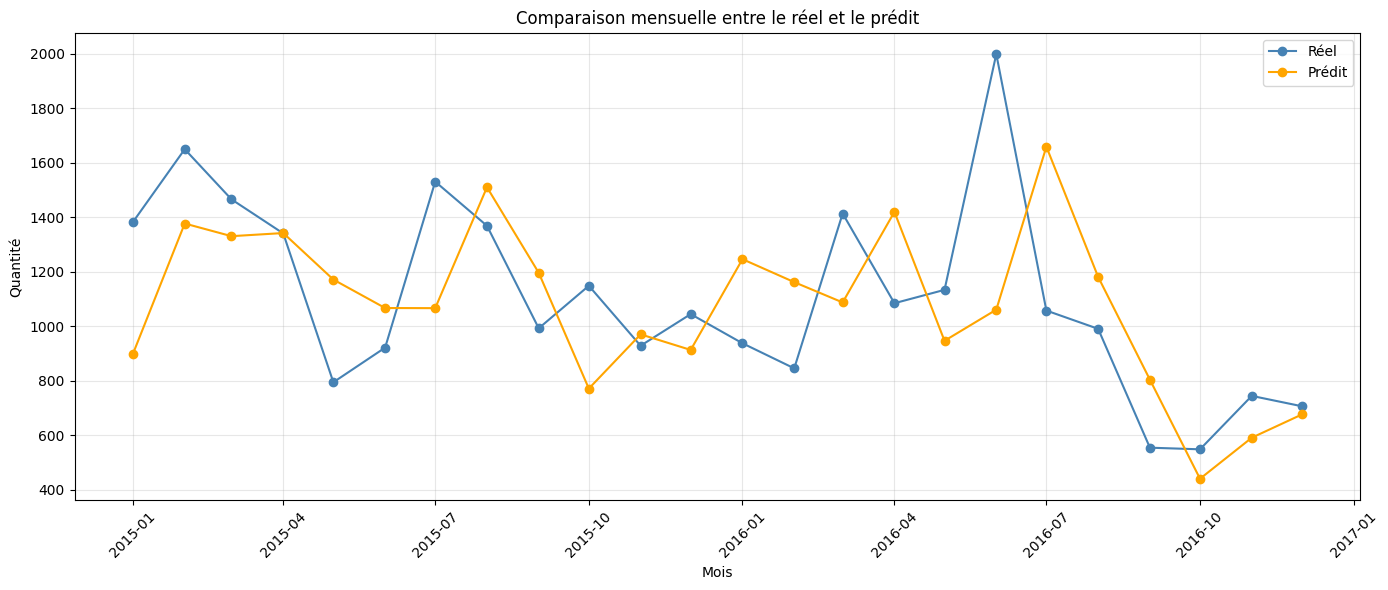

,date_mois,quantite_reelle,quantite_predite,erreur_absolue
0,2015-01-01,1383.0,899.55,812.79
1,2015-02-01,1650.0,1377.34,406.38
2,2015-03-01,1466.0,1330.93,279.60
3,2015-04-01,1341.0,1342.42,242.38
4,2015-05-01,795.0,1171.73,491.13


In [15]:
# Prédictions historiques mensuelles

comparaison_predictions = pd.read_sql_query(
    """
    SELECT
        date_mois,
        ROUND(quantite_reelle, 2)
            AS quantite_reelle,
        ROUND(quantite_predite, 2)
            AS quantite_predite,
        ROUND(erreur_absolue, 2)
            AS erreur_absolue
    FROM vw_predictions_monthly
    ORDER BY date_mois
    """,
    connexion
)

comparaison_predictions["date_mois"] = pd.to_datetime(
    comparaison_predictions["date_mois"]
)

comparaison_predictions.to_csv(
    f"{REPORTS_PATH}/comparaison_predictions_sql.csv",
    index=False
)

# Graphique

plt.figure(figsize=(14, 6))

plt.plot(
    comparaison_predictions["date_mois"],
    comparaison_predictions["quantite_reelle"],
    marker="o",
    label="Réel",
    color="steelblue"
)

plt.plot(
    comparaison_predictions["date_mois"],
    comparaison_predictions["quantite_predite"],
    marker="o",
    label="Prédit",
    color="orange"
)

plt.title(
    "Comparaison mensuelle entre le réel et le prédit"
)

plt.xlabel("Mois")
plt.ylabel("Quantité")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    f"{FIGURES_PATH}/comparaison_predictions_sql.png"
)

plt.show()
plt.close()

comparaison_predictions.head()

In [16]:
# Prévisions futures mensuelles

previsions_futures = pd.read_sql_query(
    """
    SELECT
        date_mois,
        ROUND(demande_predite, 2)
            AS demande_predite,
        stock_securite,
        stock_recommande
    FROM vw_forecast_monthly
    ORDER BY date_mois
    """,
    connexion
)

previsions_futures["date_mois"] = pd.to_datetime(
    previsions_futures["date_mois"]
)

previsions_futures.to_csv(
    f"{REPORTS_PATH}/previsions_futures_sql.csv",
    index=False
)

print(
    "Période :",
    previsions_futures["date_mois"].min(),
    "au",
    previsions_futures["date_mois"].max()
)

previsions_futures

Période : 2017-01-01 00:00:00 au 2017-12-01 00:00:00


,date_mois,demande_predite,stock_securite,stock_recommande
0,2017-01-01,948.47,1239,2200
1,2017-02-01,941.28,1239,2187
2,2017-03-01,1041.22,1239,2287
3,2017-04-01,941.28,1239,2187
4,2017-05-01,1100.34,1239,2346
5,2017-06-01,941.28,1239,2187
6,2017-07-01,965.99,1239,2212
7,2017-08-01,941.28,1239,2187
8,2017-09-01,929.13,1239,2175
9,2017-10-01,933.21,1239,2179


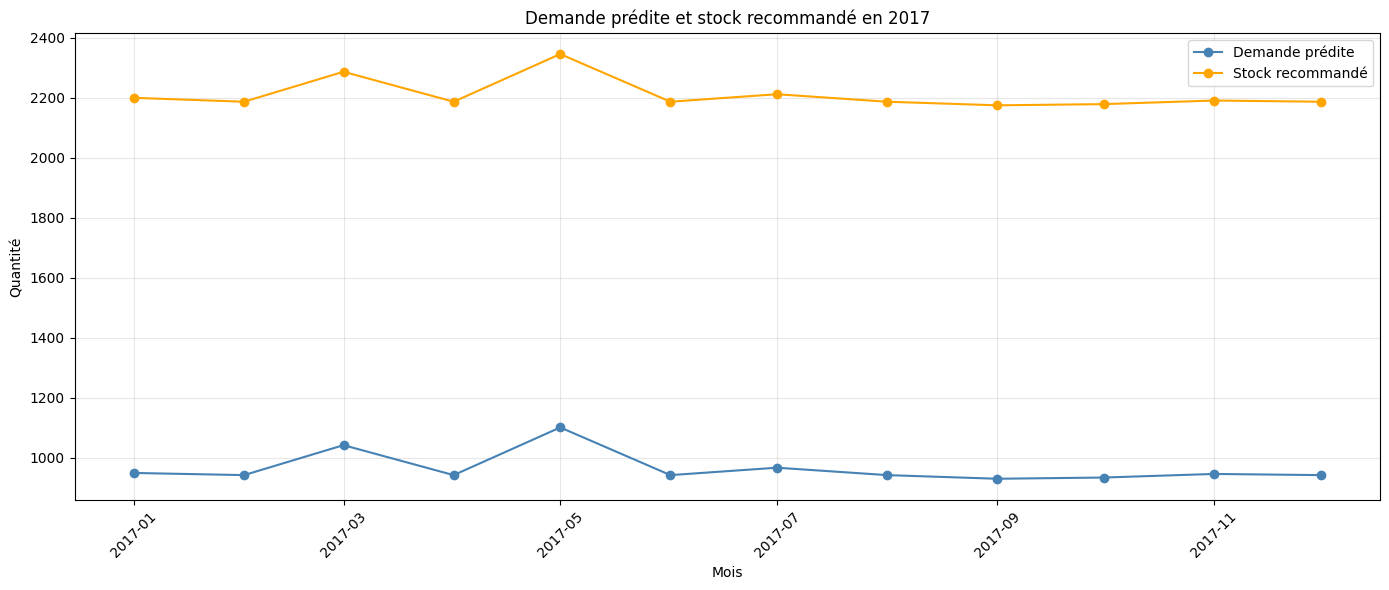

In [17]:
# Graphique des prévisions futures

plt.figure(figsize=(14, 6))

plt.plot(
    previsions_futures["date_mois"],
    previsions_futures["demande_predite"],
    marker="o",
    label="Demande prédite",
    color="steelblue"
)

plt.plot(
    previsions_futures["date_mois"],
    previsions_futures["stock_recommande"],
    marker="o",
    label="Stock recommandé",
    color="orange"
)

plt.title(
    "Demande prédite et stock recommandé en 2017"
)

plt.xlabel("Mois")
plt.ylabel("Quantité")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    f"{FIGURES_PATH}/previsions_futures_sql.png"
)

plt.show()
plt.close()

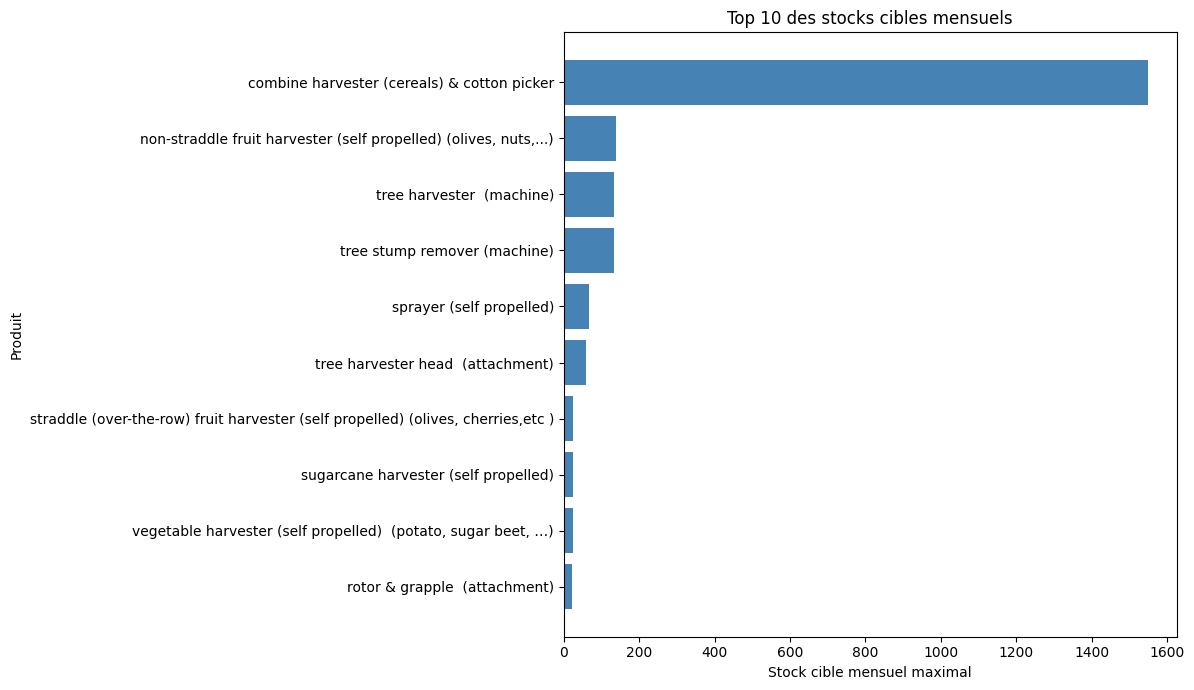

,produit,categorie_produit_2,demande_annuelle_predite,stock_cible_moyen,stock_cible_max
0,combine harvester (cereals) & cotton picker,"cereals, cotton, & feed/forage harvesting",10014.13,1410.92,1548
1,non-straddle fruit harvester (self propelled) ...,"wine, fruit, vegetable & cane equipment",118.32,139.00,139
2,tree harvester (machine),forestry,100.84,70.58,134
3,tree stump remover (machine),forestry,42.08,133.08,134
4,sprayer (self propelled),soil & crop treatment,141.84,68.00,68
5,tree harvester head (attachment),forestry,160.40,44.54,58
6,straddle (over-the-row) fruit harvester (self ...,"wine, fruit, vegetable & cane equipment",58.76,25.08,26
7,sugarcane harvester (self propelled),"wine, fruit, vegetable & cane equipment",118.14,25.00,25
8,"vegetable harvester (self propelled) (potato,...","wine, fruit, vegetable & cane equipment",118.26,25.00,25
9,rotor & grapple (attachment),forestry,58.76,20.08,21


In [18]:
# Produits avec le stock cible le plus élevé

stock_produits = pd.read_sql_query(
    """
    SELECT
        produit,
        categorie_produit_2,
        ROUND(demande_annuelle_predite, 2)
            AS demande_annuelle_predite,
        ROUND(stock_cible_moyen, 2)
            AS stock_cible_moyen,
        stock_cible_max
    FROM vw_stock_by_product
    ORDER BY stock_cible_max DESC
    LIMIT 10
    """,
    connexion
)

stock_produits.to_csv(
    f"{REPORTS_PATH}/stock_produits_sql.csv",
    index=False
)

# Graphique

plt.figure(figsize=(12, 7))

plt.barh(
    stock_produits["produit"],
    stock_produits["stock_cible_max"],
    color="steelblue"
)

plt.title(
    "Top 10 des stocks cibles mensuels"
)

plt.xlabel("Stock cible mensuel maximal")
plt.ylabel("Produit")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(
    f"{FIGURES_PATH}/stock_produits_sql.png"
)

plt.show()
plt.close()

stock_produits

In [19]:
# Vérification des relations

erreurs_relations = pd.read_sql_query(
    """
    PRAGMA foreign_key_check
    """,
    connexion
)

print(
    "Erreurs de relations :",
    len(erreurs_relations)
)

assert len(erreurs_relations) == 0

# Vérification des tables principales

tables_principales = [
    "dim_date",
    "dim_product",
    "dim_region",
    "fact_sales",
    "fact_predictions",
    "fact_stock_forecast",
    "model_metrics"
]

assert set(
    tables_principales
).issubset(
    set(tables["name"])
)

# Fermeture

connexion.close()

# Fichiers attendus

fichiers_crees = [
    f"{REPORTS_PATH}/verification_tables.csv",
    f"{REPORTS_PATH}/ventes_mensuelles_sql.csv",
    f"{REPORTS_PATH}/top_produits_sql.csv",
    f"{REPORTS_PATH}/modeles_sql.csv",
    f"{REPORTS_PATH}/comparaison_predictions_sql.csv",
    f"{REPORTS_PATH}/previsions_futures_sql.csv",
    f"{REPORTS_PATH}/stock_produits_sql.csv",
    f"{FIGURES_PATH}/comparaison_predictions_sql.png",
    f"{FIGURES_PATH}/previsions_futures_sql.png",
    f"{FIGURES_PATH}/stock_produits_sql.png"
]

for fichier in fichiers_crees:
    print(
        fichier,
        os.path.exists(fichier)
    )

print("Connexion fermée")
print("Requêtes exécutées avec succès")

Erreurs de relations : 0
../reports/database/verification_tables.csv True
../reports/database/ventes_mensuelles_sql.csv True
../reports/database/top_produits_sql.csv True
../reports/database/modeles_sql.csv True
../reports/database/comparaison_predictions_sql.csv True
../reports/database/previsions_futures_sql.csv True
../reports/database/stock_produits_sql.csv True
../reports/figures/database/comparaison_predictions_sql.png True
../reports/figures/database/previsions_futures_sql.png True
../reports/figures/database/stock_produits_sql.png True
Connexion fermée
Requêtes exécutées avec succès
